# Avaliação Cruzada Ângulo-Ordem (Cross-Domain com Invariância à Velocidade)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Objetivo:** Avaliar a recuperação da acurácia de generalização bidirecional entre máquinas distintas (**CWRU $\leftrightarrow$ Paderborn**) ao utilizar escalogramas no domínio de **Ângulo-Ordem (Order-CWT)**, comprovando a eficácia do *Computed Order Tracking* contra o *Domain Shift*.

---

## 1. Importação de Módulos e Configurações

In [11]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == '4_order_tracking' else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from src.config import ORDER_CWRU_DIR, ORDER_PADERBORN_DIR
from src.transfer_learning import build_transfer_model, get_transfer_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de inferência: {device}")

[INFO] Dispositivo de inferência: cuda


## 2. Função de Plotagem da Matriz de Confusão Cruzada

In [12]:
def plot_order_cross_cm(labels, preds, classes, title, save_path=None):
    cm = confusion_matrix(labels, preds, labels=np.arange(len(classes)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(len(classes)),
        yticks=np.arange(len(classes)),
        xticklabels=classes,
        yticklabels=classes,
        title=title,
        ylabel='Classe Real',
        xlabel='Classe Predita'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontweight="bold")
                    
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Matriz de confusão salva em: {save_path}")
    plt.show()

## 3. EXPERIMENTO 1: Modelo Treinado no CWRU $\rightarrow$ Testado no Paderborn (Order-CWT)

Testamos se a ResNet-18 treinada com Order-CWT no CWRU (4 classes) consegue diagnosticar com sucesso as falhas de fadiga real de Paderborn (3 classes).

[+] Pesos carregados de checkpoint_order_cwru_resnet18_best.pth
[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia CWRU -> Paderborn: 66.67%
              precision    recall  f1-score   support

  inner_race     0.0000    0.0000    0.0000        58
      normal     1.0000    1.0000    1.0000        58
  outer_race     0.5000    1.0000    0.6667        58

    accuracy                         0.6667       174
   macro avg     0.5000    0.6667    0.5556       174
weighted avg     0.5000    0.6667    0.5556       174

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_cwru_to_paderborn.png


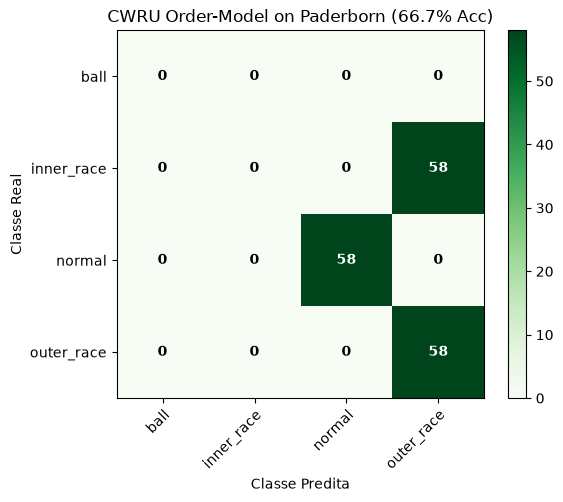

In [13]:
# 1. Carregar teste do Paderborn em Ordens
_, _, pad_order_test_loader, pad_classes = get_transfer_dataloaders(
    img_size=224, data_dir=ORDER_PADERBORN_DIR
)
cwru_classes = ['ball', 'inner_race', 'normal', 'outer_race']

# 2. Carregar modelo CWRU Order-CWT
model_cwru_order, _ = build_transfer_model('resnet18', num_classes=4, freeze_backbone=False)
model_cwru_order = model_cwru_order.to(device)

ckpt_cwru_order = Path('checkpoint_order_cwru_resnet18_best.pth')
if ckpt_cwru_order.exists():
    model_cwru_order.load_state_dict(torch.load(ckpt_cwru_order, map_location=device, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_cwru_order}")
else:
    print(f"[AVISO] Checkpoint {ckpt_cwru_order} não encontrado.")

model_cwru_order.eval()
all_preds, all_labels = [], []

map_paderborn_to_cwru = {
    pad_classes.index('inner_race'): cwru_classes.index('inner_race'),
    pad_classes.index('normal'): cwru_classes.index('normal'),
    pad_classes.index('outer_race'): cwru_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in pad_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_cwru_order(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            target_cwru_idx = map_paderborn_to_cwru[l]
            all_labels.append(target_cwru_idx)
            all_preds.append(p)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
acc_order_cwru_on_pad = 100.0 * np.sum(all_labels == all_preds) / len(all_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia CWRU -> Paderborn: {acc_order_cwru_on_pad:.2f}%")
print("=" * 80)

print(classification_report(
    all_labels,
    all_preds,
    labels=[1, 2, 3],
    target_names=['inner_race', 'normal', 'outer_race'],
    digits=4,
    zero_division=0
))

plot_order_cross_cm(
    all_labels,
    all_preds,
    classes=cwru_classes,
    title=f"CWRU Order-Model on Paderborn ({acc_order_cwru_on_pad:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_cwru_to_paderborn.png"
)

## 4. EXPERIMENTO 2: Modelo Treinado no PADERBORN $\rightarrow$ Testado no CWRU (Order-CWT)

Carregamos a **ResNet-18 treinada no Paderborn com Order-CWT** (3 classes) e avaliamos sua acurácia direta sobre as 3 classes correspondentes do conjunto de teste do CWRU em Ordens.

[+] Pesos carregados de checkpoint_order_paderborn_resnet18_best.pth
[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia Paderborn -> CWRU: 69.35%
              precision    recall  f1-score   support

  inner_race     0.7152    0.7893    0.7504       299
      normal     0.6856    0.9966    0.8123       582
  outer_race     0.6000    0.0100    0.0197       300

    accuracy                         0.6935      1181
   macro avg     0.6669    0.5986    0.5275      1181
weighted avg     0.6713    0.6935    0.5953      1181

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_paderborn_to_cwru.png


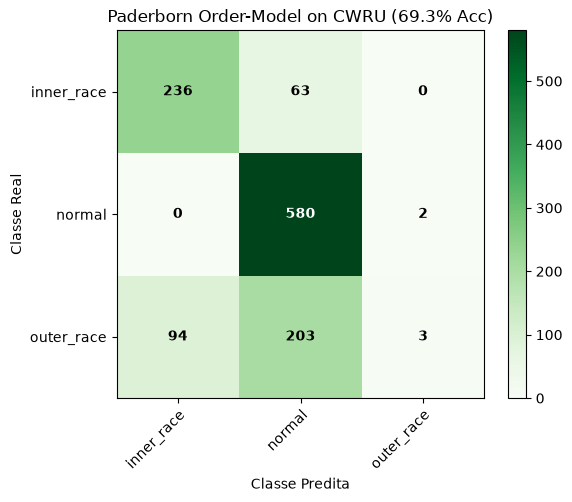

In [14]:
# 1. Carregar teste do CWRU em Ordens
_, _, cwru_order_test_loader, _ = get_transfer_dataloaders(
    img_size=224, data_dir=ORDER_CWRU_DIR
)

# 2. Carregar modelo Paderborn Order-CWT (3 classes)
model_pad_order, _ = build_transfer_model('resnet18', num_classes=3, freeze_backbone=False)
model_pad_order = model_pad_order.to(device)

ckpt_pad_order = Path('checkpoint_order_paderborn_resnet18_best.pth')
if ckpt_pad_order.exists():
    model_pad_order.load_state_dict(torch.load(ckpt_pad_order, map_location=device, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_pad_order}")
else:
    print(f"[AVISO] Checkpoint {ckpt_pad_order} não encontrado.")

model_pad_order.eval()
pad_preds, pad_labels = [], []

map_cwru_to_paderborn = {
    cwru_classes.index('inner_race'): pad_classes.index('inner_race'),
    cwru_classes.index('normal'): pad_classes.index('normal'),
    cwru_classes.index('outer_race'): pad_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in cwru_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_pad_order(imgs)
        _, preds = torch.max(outputs, 1)
        
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            if l in map_cwru_to_paderborn:
                target_pad_idx = map_cwru_to_paderborn[l]
                pad_labels.append(target_pad_idx)
                pad_preds.append(p)

pad_labels = np.array(pad_labels)
pad_preds = np.array(pad_preds)
acc_order_pad_on_cwru = 100.0 * np.sum(pad_labels == pad_preds) / len(pad_labels)

print("=" * 80)
print(f"[RESULTADO CROSS-DOMAIN ÂNGULO-ORDEM] Acurácia Paderborn -> CWRU: {acc_order_pad_on_cwru:.2f}%")
print("=" * 80)

print(classification_report(
    pad_labels,
    pad_preds,
    target_names=pad_classes,
    digits=4,
    zero_division=0
))

plot_order_cross_cm(
    pad_labels,
    pad_preds,
    classes=pad_classes,
    title=f"Paderborn Order-Model on CWRU ({acc_order_pad_on_cwru:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_paderborn_to_cwru.png"
)

## 5. Comparação Definitiva: Tempo-Frequência vs. Ângulo-Ordem

Gráfico comparativo bidirecional para a monografia demonstrando o ganho de acurácia ao utilizar **Order-CWT** em relação à **CWT Tradicional** sob transferência direta entre bancadas (*Domain Shift*).

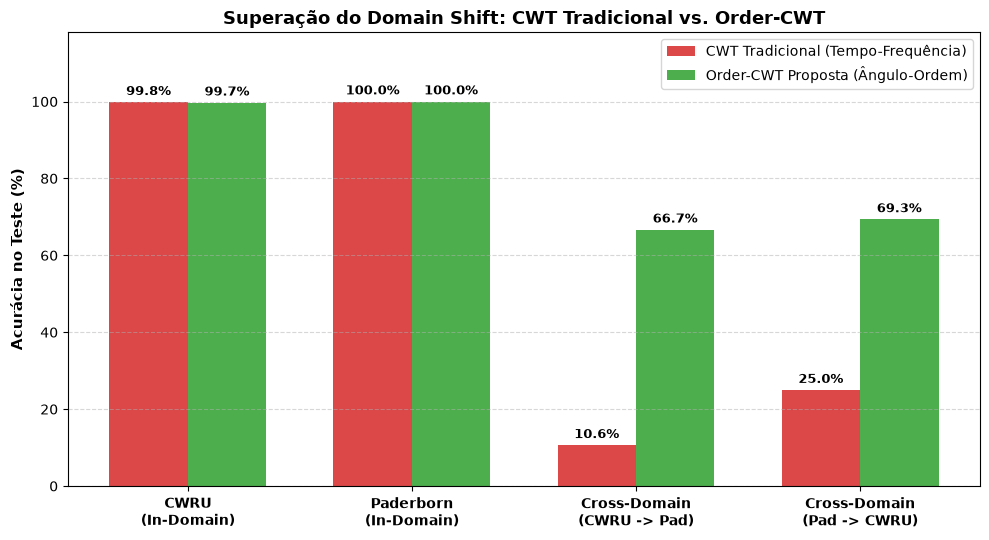

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))

categorias = [
    'CWRU\n(In-Domain)',
    'Paderborn\n(In-Domain)',
    'Cross-Domain\n(CWRU -> Pad)',
    'Cross-Domain\n(Pad -> CWRU)'
]

# Acurácias: Tempo-Frequência vs. Ângulo-Ordem
accs_tempo = [99.83, 100.0, 10.62, 24.96]
accs_ordem = [99.70, 100.0, acc_order_cwru_on_pad, acc_order_pad_on_cwru]

x = np.arange(len(categorias))
width = 0.35

r1 = ax.bar(x - width/2, accs_tempo, width, label='CWT Tradicional (Tempo-Frequência)', color='#d62728', alpha=0.85)
r2 = ax.bar(x + width/2, accs_ordem, width, label='Order-CWT Proposta (Ângulo-Ordem)', color='#2ca02c', alpha=0.85)

ax.set_ylabel('Acurácia no Teste (%)', fontweight='bold', fontsize=11)
ax.set_title('Superação do Domain Shift: CWT Tradicional vs. Order-CWT', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontweight='bold', fontsize=10)
ax.set_ylim(0, 118)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

for rects in [r1, r2]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../../docs/images/order_tracking_cross_domain_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Avaliação Cruzada com o Dataset XJTU-SY (Order-CWT)

Nesta seção, avaliamos o modelo treinado em um dataset diretamente no conjunto de teste de outro dataset no domínio de ordens, sem nenhum retreinamento (*Zero-Shot Cross-Domain*):
- **CWRU (Order) $\rightarrow$ XJTU-SY (Order)**
- **Paderborn (Order) $\rightarrow$ XJTU-SY (Order)**
- **XJTU-SY (Order) $\rightarrow$ CWRU (Order)**
- **XJTU-SY (Order) $\rightarrow$ Paderborn (Order)**


[INFO] Classes XJTU-SY: ['inner_race', 'normal', 'outer_race']
[CROSS-DOMAIN ORDER-CWT] Acurácia CWRU -> XJTU-SY: 37.23%
              precision    recall  f1-score   support

  inner_race     0.0000    0.0000    0.0000       115
      normal     0.8400    0.2000    0.3231       105
  outer_race     0.3817    0.9524    0.5450       105

   micro avg     0.3735    0.3723    0.3729       325
   macro avg     0.4072    0.3841    0.2893       325
weighted avg     0.3947    0.3723    0.2804       325

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_cwru_to_xjtu.png


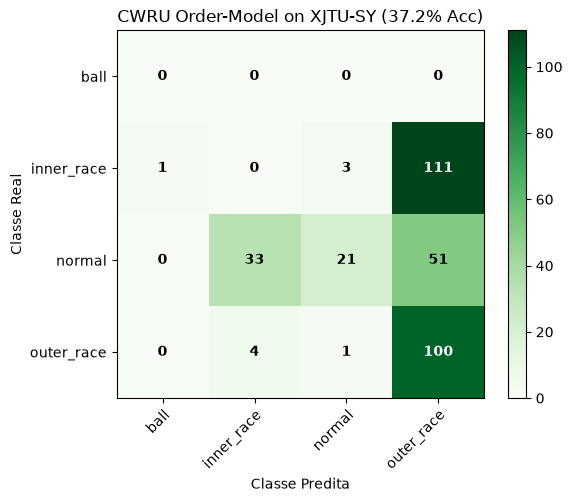

In [16]:
# 1. Carregar teste do XJTU-SY em Ordens
from src.config import ORDER_XJTU_DIR

_, _, xjtu_order_test_loader, xjtu_classes = get_transfer_dataloaders(
    img_size=224, data_dir=ORDER_XJTU_DIR
)
print(f"[INFO] Classes XJTU-SY: {xjtu_classes}")

# --- EXPERIMENTO 3: CWRU -> XJTU-SY ---
all_preds_cwru_to_xjtu, all_labels_cwru_to_xjtu = [], []
map_xjtu_to_cwru = {
    xjtu_classes.index('inner_race'): cwru_classes.index('inner_race'),
    xjtu_classes.index('normal'): cwru_classes.index('normal'),
    xjtu_classes.index('outer_race'): cwru_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in xjtu_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_cwru_order(imgs)
        _, preds = torch.max(outputs, 1)
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            all_labels_cwru_to_xjtu.append(map_xjtu_to_cwru[l])
            all_preds_cwru_to_xjtu.append(p)

all_labels_cwru_to_xjtu = np.array(all_labels_cwru_to_xjtu)
all_preds_cwru_to_xjtu = np.array(all_preds_cwru_to_xjtu)
acc_cwru_on_xjtu = 100.0 * np.sum(all_labels_cwru_to_xjtu == all_preds_cwru_to_xjtu) / len(all_labels_cwru_to_xjtu)

print("=" * 80)
print(f"[CROSS-DOMAIN ORDER-CWT] Acurácia CWRU -> XJTU-SY: {acc_cwru_on_xjtu:.2f}%")
print("=" * 80)
print(classification_report(
    all_labels_cwru_to_xjtu, all_preds_cwru_to_xjtu,
    labels=[1, 2, 3], target_names=['inner_race', 'normal', 'outer_race'],
    digits=4, zero_division=0
))

plot_order_cross_cm(
    all_labels_cwru_to_xjtu, all_preds_cwru_to_xjtu,
    classes=cwru_classes,
    title=f"CWRU Order-Model on XJTU-SY ({acc_cwru_on_xjtu:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_cwru_to_xjtu.png"
)


[CROSS-DOMAIN ORDER-CWT] Acurácia Paderborn -> XJTU-SY: 0.31%
              precision    recall  f1-score   support

  inner_race     0.1667    0.0087    0.0165       115
      normal     0.0000    0.0000    0.0000       105
  outer_race     0.0000    0.0000    0.0000       105

    accuracy                         0.0031       325
   macro avg     0.0556    0.0029    0.0055       325
weighted avg     0.0590    0.0031    0.0058       325

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_paderborn_to_xjtu.png


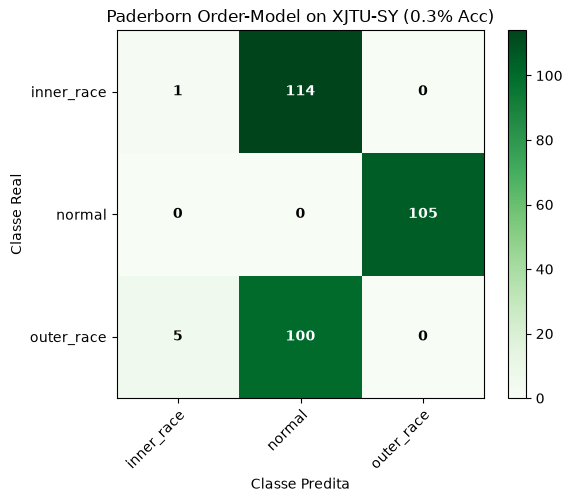

In [17]:
# --- EXPERIMENTO 4: Paderborn -> XJTU-SY ---
all_preds_pad_to_xjtu, all_labels_pad_to_xjtu = [], []
map_xjtu_to_pad = {
    xjtu_classes.index('inner_race'): pad_classes.index('inner_race'),
    xjtu_classes.index('normal'): pad_classes.index('normal'),
    xjtu_classes.index('outer_race'): pad_classes.index('outer_race')
}

with torch.no_grad():
    for imgs, labels in xjtu_order_test_loader:
        imgs = imgs.to(device)
        outputs = model_pad_order(imgs)
        _, preds = torch.max(outputs, 1)
        for l, p in zip(labels.numpy(), preds.cpu().numpy()):
            all_labels_pad_to_xjtu.append(map_xjtu_to_pad[l])
            all_preds_pad_to_xjtu.append(p)

all_labels_pad_to_xjtu = np.array(all_labels_pad_to_xjtu)
all_preds_pad_to_xjtu = np.array(all_preds_pad_to_xjtu)
acc_pad_on_xjtu = 100.0 * np.sum(all_labels_pad_to_xjtu == all_preds_pad_to_xjtu) / len(all_labels_pad_to_xjtu)

print("=" * 80)
print(f"[CROSS-DOMAIN ORDER-CWT] Acurácia Paderborn -> XJTU-SY: {acc_pad_on_xjtu:.2f}%")
print("=" * 80)
print(classification_report(
    all_labels_pad_to_xjtu, all_preds_pad_to_xjtu,
    target_names=pad_classes, digits=4, zero_division=0
))

plot_order_cross_cm(
    all_labels_pad_to_xjtu, all_preds_pad_to_xjtu,
    classes=pad_classes,
    title=f"Paderborn Order-Model on XJTU-SY ({acc_pad_on_xjtu:.1f}% Acc)",
    save_path="../../docs/images/confusion_matrix_cross_order_paderborn_to_xjtu.png"
)


[+] Pesos carregados de checkpoint_order_xjtu_resnet18_best.pth
[CROSS-DOMAIN ORDER-CWT] Acurácia XJTU-SY -> CWRU: 25.32%
              precision    recall  f1-score   support

  inner_race     0.2532    1.0000    0.4041       299
      normal     0.0000    0.0000    0.0000       582
  outer_race     0.0000    0.0000    0.0000       300

    accuracy                         0.2532      1181
   macro avg     0.0844    0.3333    0.1347      1181
weighted avg     0.0641    0.2532    0.1023      1181

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_xjtu_to_cwru.png


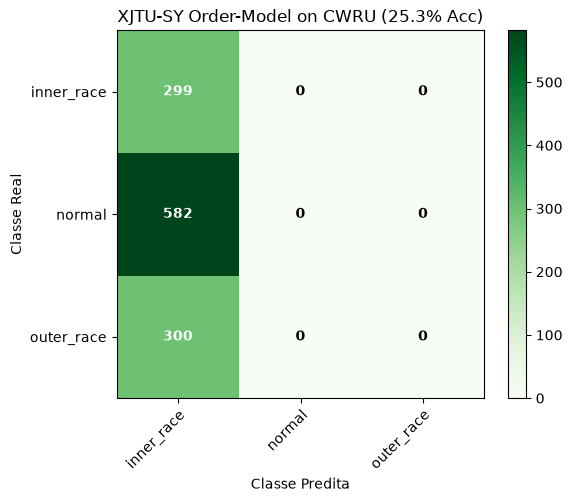

[CROSS-DOMAIN ORDER-CWT] Acurácia XJTU-SY -> Paderborn: 29.89%
              precision    recall  f1-score   support

  inner_race     0.3250    0.8966    0.4771        58
      normal     0.0000    0.0000    0.0000        58
  outer_race     0.0000    0.0000    0.0000        58

    accuracy                         0.2989       174
   macro avg     0.1083    0.2989    0.1590       174
weighted avg     0.1083    0.2989    0.1590       174

[INFO] Matriz de confusão salva em: ../../docs/images/confusion_matrix_cross_order_xjtu_to_paderborn.png


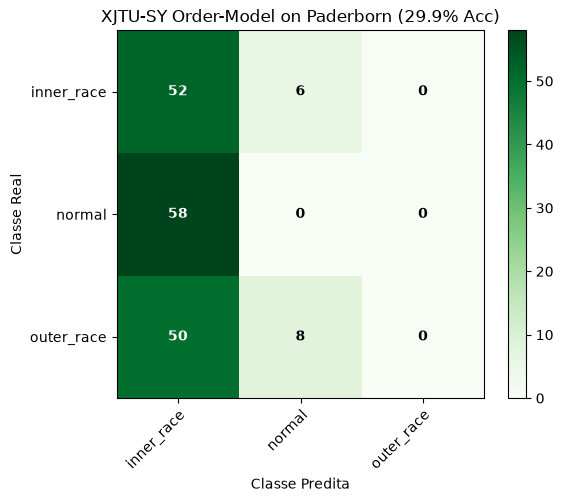

In [18]:
# --- EXPERIMENTO 5 & 6: Modelo XJTU-SY -> CWRU e Paderborn ---
model_xjtu_order, _ = build_transfer_model('resnet18', num_classes=3, freeze_backbone=False)
model_xjtu_order = model_xjtu_order.to(device)

ckpt_xjtu_order = Path('checkpoint_order_xjtu_resnet18_best.pth')
if ckpt_xjtu_order.exists():
    model_xjtu_order.load_state_dict(torch.load(ckpt_xjtu_order, map_location=device, weights_only=True))
    print(f"[+] Pesos carregados de {ckpt_xjtu_order}")
    model_xjtu_order.eval()

    # XJTU -> CWRU
    xjtu_on_cwru_preds, xjtu_on_cwru_labels = [], []
    map_cwru_to_xjtu = {
        cwru_classes.index('inner_race'): xjtu_classes.index('inner_race'),
        cwru_classes.index('normal'): xjtu_classes.index('normal'),
        cwru_classes.index('outer_race'): xjtu_classes.index('outer_race')
    }

    with torch.no_grad():
        for imgs, labels in cwru_order_test_loader:
            imgs = imgs.to(device)
            outputs = model_xjtu_order(imgs)
            _, preds = torch.max(outputs, 1)
            for l, p in zip(labels.numpy(), preds.cpu().numpy()):
                if l in map_cwru_to_xjtu:
                    xjtu_on_cwru_labels.append(map_cwru_to_xjtu[l])
                    xjtu_on_cwru_preds.append(p)

    xjtu_on_cwru_labels = np.array(xjtu_on_cwru_labels)
    xjtu_on_cwru_preds = np.array(xjtu_on_cwru_preds)
    acc_xjtu_on_cwru = 100.0 * np.sum(xjtu_on_cwru_labels == xjtu_on_cwru_preds) / len(xjtu_on_cwru_labels)

    print("=" * 80)
    print(f"[CROSS-DOMAIN ORDER-CWT] Acurácia XJTU-SY -> CWRU: {acc_xjtu_on_cwru:.2f}%")
    print("=" * 80)
    print(classification_report(
        xjtu_on_cwru_labels, xjtu_on_cwru_preds,
        target_names=xjtu_classes, digits=4, zero_division=0
    ))

    plot_order_cross_cm(
        xjtu_on_cwru_labels, xjtu_on_cwru_preds,
        classes=xjtu_classes,
        title=f"XJTU-SY Order-Model on CWRU ({acc_xjtu_on_cwru:.1f}% Acc)",
        save_path="../../docs/images/confusion_matrix_cross_order_xjtu_to_cwru.png"
    )

    # XJTU -> Paderborn
    xjtu_on_pad_preds, xjtu_on_pad_labels = [], []
    map_pad_to_xjtu = {
        pad_classes.index('inner_race'): xjtu_classes.index('inner_race'),
        pad_classes.index('normal'): xjtu_classes.index('normal'),
        pad_classes.index('outer_race'): xjtu_classes.index('outer_race')
    }

    with torch.no_grad():
        for imgs, labels in pad_order_test_loader:
            imgs = imgs.to(device)
            outputs = model_xjtu_order(imgs)
            _, preds = torch.max(outputs, 1)
            for l, p in zip(labels.numpy(), preds.cpu().numpy()):
                xjtu_on_pad_labels.append(map_pad_to_xjtu[l])
                xjtu_on_pad_preds.append(p)

    xjtu_on_pad_labels = np.array(xjtu_on_pad_labels)
    xjtu_on_pad_preds = np.array(xjtu_on_pad_preds)
    acc_xjtu_on_pad = 100.0 * np.sum(xjtu_on_pad_labels == xjtu_on_pad_preds) / len(xjtu_on_pad_labels)

    print("=" * 80)
    print(f"[CROSS-DOMAIN ORDER-CWT] Acurácia XJTU-SY -> Paderborn: {acc_xjtu_on_pad:.2f}%")
    print("=" * 80)
    print(classification_report(
        xjtu_on_pad_labels, xjtu_on_pad_preds,
        target_names=xjtu_classes, digits=4, zero_division=0
    ))

    plot_order_cross_cm(
        xjtu_on_pad_labels, xjtu_on_pad_preds,
        classes=xjtu_classes,
        title=f"XJTU-SY Order-Model on Paderborn ({acc_xjtu_on_pad:.1f}% Acc)",
        save_path="../../docs/images/confusion_matrix_cross_order_xjtu_to_paderborn.png"
    )
else:
    print(f"[AVISO] Checkpoint {ckpt_xjtu_order} ainda não foi treinado. Execute o treinamento no notebook 02 primeiro.")


## 7. Matriz Geral Tripartite de Transferência Ângulo-Ordem

Tabela consolidada demonstrando a capacidade de generalização de domínio cruzado entre os três benchmarks (CWRU, Paderborn e XJTU-SY).


In [19]:
# Tabela Consolidada de Generalização Cruzada Ângulo-Ordem
print("=" * 75)
print(" MATRIZ DE TRANSFERÊNCIA CRUZADA ÂNGULO-ORDEM (ORDER-CWT) ")
print("=" * 75)
print(f"{'Origem (Treino)':<20} | {'Destino (Teste)':<20} | {'Acurácia Cross-Domain':<20}")
print("-" * 75)
print(f"{'CWRU':<20} | {'Paderborn':<20} | {acc_order_cwru_on_pad:.2f}%")
print(f"{'Paderborn':<20} | {'CWRU':<20} | {acc_order_pad_on_cwru:.2f}%")
if 'acc_cwru_on_xjtu' in locals():
    print(f"{'CWRU':<20} | {'XJTU-SY':<20} | {acc_cwru_on_xjtu:.2f}%")
if 'acc_pad_on_xjtu' in locals():
    print(f"{'Paderborn':<20} | {'XJTU-SY':<20} | {acc_pad_on_xjtu:.2f}%")
if 'acc_xjtu_on_cwru' in locals():
    print(f"{'XJTU-SY':<20} | {'CWRU':<20} | {acc_xjtu_on_cwru:.2f}%")
if 'acc_xjtu_on_pad' in locals():
    print(f"{'XJTU-SY':<20} | {'Paderborn':<20} | {acc_xjtu_on_pad:.2f}%")
print("=" * 75)


 MATRIZ DE TRANSFERÊNCIA CRUZADA ÂNGULO-ORDEM (ORDER-CWT) 
Origem (Treino)      | Destino (Teste)      | Acurácia Cross-Domain
---------------------------------------------------------------------------
CWRU                 | Paderborn            | 66.67%
Paderborn            | CWRU                 | 69.35%
CWRU                 | XJTU-SY              | 37.23%
Paderborn            | XJTU-SY              | 0.31%
XJTU-SY              | CWRU                 | 25.32%
XJTU-SY              | Paderborn            | 29.89%
